In [1]:
import os
os.getcwd()

'/Users/ffzhu/PycharmProjects/Unimelb-DS-Project-G19/case_study/suburb_boundary'

In [2]:
from case_study.suburb_boundary.utils import data_loader
from case_study.suburb_boundary.utils import rule_checker as rc

path = r"../../data/sa-govt-dpti-sa-suburb-boundaries-aug-2018-na.json"
data = data_loader.gpd_loader(path)

In [3]:
data

,id,ogc_fid,postcode,suburb,suburb_number,legalstartdate,shape_length,shape_area,geometry
0,sa_suburb_boundaries_aug_2018.1,1,5013,GILLMAN,501301,2009-10-21 13:00:00+00:00,0.125751,0.000384,"MULTIPOLYGON (((138.53137 -34.83256, 138.53277..."
1,sa_suburb_boundaries_aug_2018.2,2,5013,OTTOWAY,501302,1970-05-20 14:00:00+00:00,0.051287,0.000137,"MULTIPOLYGON (((138.52803 -34.85146, 138.52712..."
2,sa_suburb_boundaries_aug_2018.3,3,5013,PENNINGTON,501303,2002-10-23 14:00:00+00:00,0.056255,0.000135,"MULTIPOLYGON (((138.53824 -34.85591, 138.5385 ..."
3,sa_suburb_boundaries_aug_2018.4,4,5013,ROSEWATER,501304,2002-10-23 14:00:00+00:00,0.051478,0.000125,"MULTIPOLYGON (((138.52703 -34.8511, 138.52712 ..."
4,sa_suburb_boundaries_aug_2018.5,5,5013,WINGFIELD,501305,2009-10-21 13:00:00+00:00,0.114764,0.000690,"MULTIPOLYGON (((138.57927 -34.84941, 138.57375..."
...,...,...,...,...,...,...,...,...,...
1886,sa_suburb_boundaries_aug_2018.1887,1887,5730,BLINMAN,573003,2013-04-25 14:00:00+00:00,0.489033,0.010838,"MULTIPOLYGON (((138.72921 -31.10364, 138.7292 ..."
1887,sa_suburb_boundaries_aug_2018.1888,1888,5730,EDIACARA,573007,2013-04-25 14:00:00+00:00,0.299213,0.004511,"MULTIPOLYGON (((138.14914 -30.86023, 138.11124..."
1888,sa_suburb_boundaries_aug_2018.1889,1889,5730,GUM CREEK STATION,573008,2016-03-30 13:00:00+00:00,0.730516,0.018578,"MULTIPOLYGON (((138.74175 -31.16229, 138.7431 ..."
1889,sa_suburb_boundaries_aug_2018.1890,1890,5730,MOOLOOLOO,573009,2013-04-25 14:00:00+00:00,1.105200,0.039046,"MULTIPOLYGON (((138.53708 -30.90412, 138.53751..."


In [4]:
data.to_crs(epsg=3107)

,id,ogc_fid,postcode,suburb,suburb_number,legalstartdate,shape_length,shape_area,geometry
0,sa_suburb_boundaries_aug_2018.1,1,5013,GILLMAN,501301,2009-10-21 13:00:00+00:00,0.125751,0.000384,"MULTIPOLYGON (((1322575.291 1681199.65, 132269..."
1,sa_suburb_boundaries_aug_2018.2,2,5013,OTTOWAY,501302,1970-05-20 14:00:00+00:00,0.051287,0.000137,"MULTIPOLYGON (((1322201.413 1679116.565, 13221..."
2,sa_suburb_boundaries_aug_2018.3,3,5013,PENNINGTON,501303,2002-10-23 14:00:00+00:00,0.056255,0.000135,"MULTIPOLYGON (((1323117.6 1678593.592, 1323127..."
3,sa_suburb_boundaries_aug_2018.4,4,5013,ROSEWATER,501304,2002-10-23 14:00:00+00:00,0.051478,0.000125,"MULTIPOLYGON (((1322111.84 1679159.569, 132211..."
4,sa_suburb_boundaries_aug_2018.5,5,5013,WINGFIELD,501305,2009-10-21 13:00:00+00:00,0.114764,0.000690,"MULTIPOLYGON (((1326886.954 1679189.588, 13263..."
...,...,...,...,...,...,...,...,...,...
1886,sa_suburb_boundaries_aug_2018.1887,1887,5730,BLINMAN,573003,2013-04-25 14:00:00+00:00,0.489033,0.010838,"MULTIPOLYGON (((1354882.092 2093024.716, 13548..."
1887,sa_suburb_boundaries_aug_2018.1888,1888,5730,EDIACARA,573007,2013-04-25 14:00:00+00:00,0.299213,0.004511,"MULTIPOLYGON (((1300482.808 2121697.102, 12968..."
1888,sa_suburb_boundaries_aug_2018.1889,1889,5730,GUM CREEK STATION,573008,2016-03-30 13:00:00+00:00,0.730516,0.018578,"MULTIPOLYGON (((1355850.33 2086500.44, 1355960..."
1889,sa_suburb_boundaries_aug_2018.1890,1890,5730,MOOLOOLOO,573009,2013-04-25 14:00:00+00:00,1.105200,0.039046,"MULTIPOLYGON (((1337327.686 2115699.168, 13373..."


# 1. Geometric Validity  

What to Check:
- All geometries are valid (no self-intersections, open rings, etc.).
- Polygons are closed and non-degenerate (area > 0).

> Any invalid records (unbounded etc.)?

In [5]:
_ = rc.check_geometries(data)

0 invalid geometries found.


> Any suburbs with non-positive bounded area?

In [6]:
_ = rc.check_areas(data, reproject_epsg=None)

0 suburbs with area <= 0 found.


/Users/ffzhu/PycharmProjects/Unimelb-DS-Project-G19/case_study/suburb_boundary/utils/rule_checker.py:39: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  invalid_areas = gdf[gdf['geometry'].area <= 0]


This happens because GeoJSON is in a default geographic coordinate system (CRS) (EPSG:4326), which uses latitude and longitude in degrees. Measuring area in degrees doesn't make sense — it's not a unit of physical distance or area.

In [7]:
_ = rc.check_areas(data, reproject_epsg=3107)

0 suburbs with area <= 0 found.


# 2. Topological Consistency 


What to Check:

- No overlapping suburbs.
- No topological gaps between adjacent polygons.
- Shared boundaries should align exactly (no slivers).

> **Any overlapping suburbs?**
> The unit of intersection.area is square meters (m²)

In [8]:
rc.check_overlaps(data.to_crs(epsg=3107))

14 overlaps found.


,suburb_1,suburb_2,intersection_area
0,HILLCREST,KLEMZIG,0.008788
1,GREENACRES,KLEMZIG,0.073016
2,ELIZABETH SOUTH,ELIZABETH,0.048606
3,ELIZABETH SOUTH,ELIZABETH GROVE,0.042835
4,PENFIELD,EDINBURGH NORTH,0.004568
5,HILLIER,BUCHFELDE,3.568916
6,CASSINI,STOKES BAY,0.316737
7,MIDDLE RIVER,STOKES BAY,0.103299
8,PORT NOARLUNGA,NOARLUNGA DOWNS,0.165612
9,VICTOR HARBOR,HINDMARSH VALLEY,1.499450


In [9]:
rc.check_gaps(data)

✅ No topological gaps found.


In [10]:
gdf_issues = rc.check_misaligned_boundaries(data)

0 inconsistent boundaries detected.


# 3. Semantic Accuracy
***Ensure semantic attributes align with geometry***

What to Check:

- Suburb names are unique per polygon or consistent across parts of MultiPolygons.
- postcode and suburb_number match expected ranges or constraints.
- Suburbs have a legal start date (not null and in valid format).

> Missing/incomplete values?

In [11]:
duplicate_suburbs, missing_postcode,invalid_dates = rc.check_semantics(data)

27 suburbs with invalid legal start date.


In [12]:
invalid_dates

,id,ogc_fid,postcode,suburb,suburb_number,legalstartdate,shape_length,shape_area,geometry
12,sa_suburb_boundaries_aug_2018.25,25,0872,MURPUTJA,87213,NaT,0.032455,0.000064,"POLYGON ((130.1854 -26.16962, 130.18349 -26.17..."
15,sa_suburb_boundaries_aug_2018.15,15,0872,AMATA,87206,NaT,0.258467,0.003273,"POLYGON ((131.21647 -26.11914, 131.14123 -26.1..."
16,sa_suburb_boundaries_aug_2018.16,16,0872,ANANGU PITJANTJATJARA YANKUNYTJATJARA,87205,NaT,16.039189,9.288721,"POLYGON ((132.97729 -25.99857, 133.05763 -25.9..."
19,sa_suburb_boundaries_aug_2018.19,19,0872,IWANTJA,87209,NaT,0.143983,0.001144,"POLYGON ((133.30662 -26.9931, 133.30002 -26.99..."
20,sa_suburb_boundaries_aug_2018.20,20,0872,KALKA,87210,NaT,0.074435,0.000288,"POLYGON ((129.1684 -26.12032, 129.14924 -26.12..."
21,sa_suburb_boundaries_aug_2018.21,21,0872,KALTJITI,87208,NaT,0.108854,0.000688,"POLYGON ((132.02061 -26.78362, 132.01478 -26.7..."
22,sa_suburb_boundaries_aug_2018.22,22,0872,KANPI,87211,NaT,0.120691,0.000600,"POLYGON ((130.13615 -26.18268, 130.13415 -26.1..."
24,sa_suburb_boundaries_aug_2018.24,24,0872,MIMILI,87212,NaT,0.146909,0.001397,"POLYGON ((132.72175 -27.02324, 132.70043 -27.0..."
25,sa_suburb_boundaries_aug_2018.26,26,0872,NYAPARI,87214,NaT,0.123339,0.000811,"POLYGON ((130.23157 -26.1897, 130.19913 -26.19..."
26,sa_suburb_boundaries_aug_2018.27,27,0872,PIPALYATJARA,87215,NaT,0.159115,0.001431,"POLYGON ((129.16832 -26.17279, 129.13193 -26.1..."


In [13]:
import matplotlib.pyplot as plt

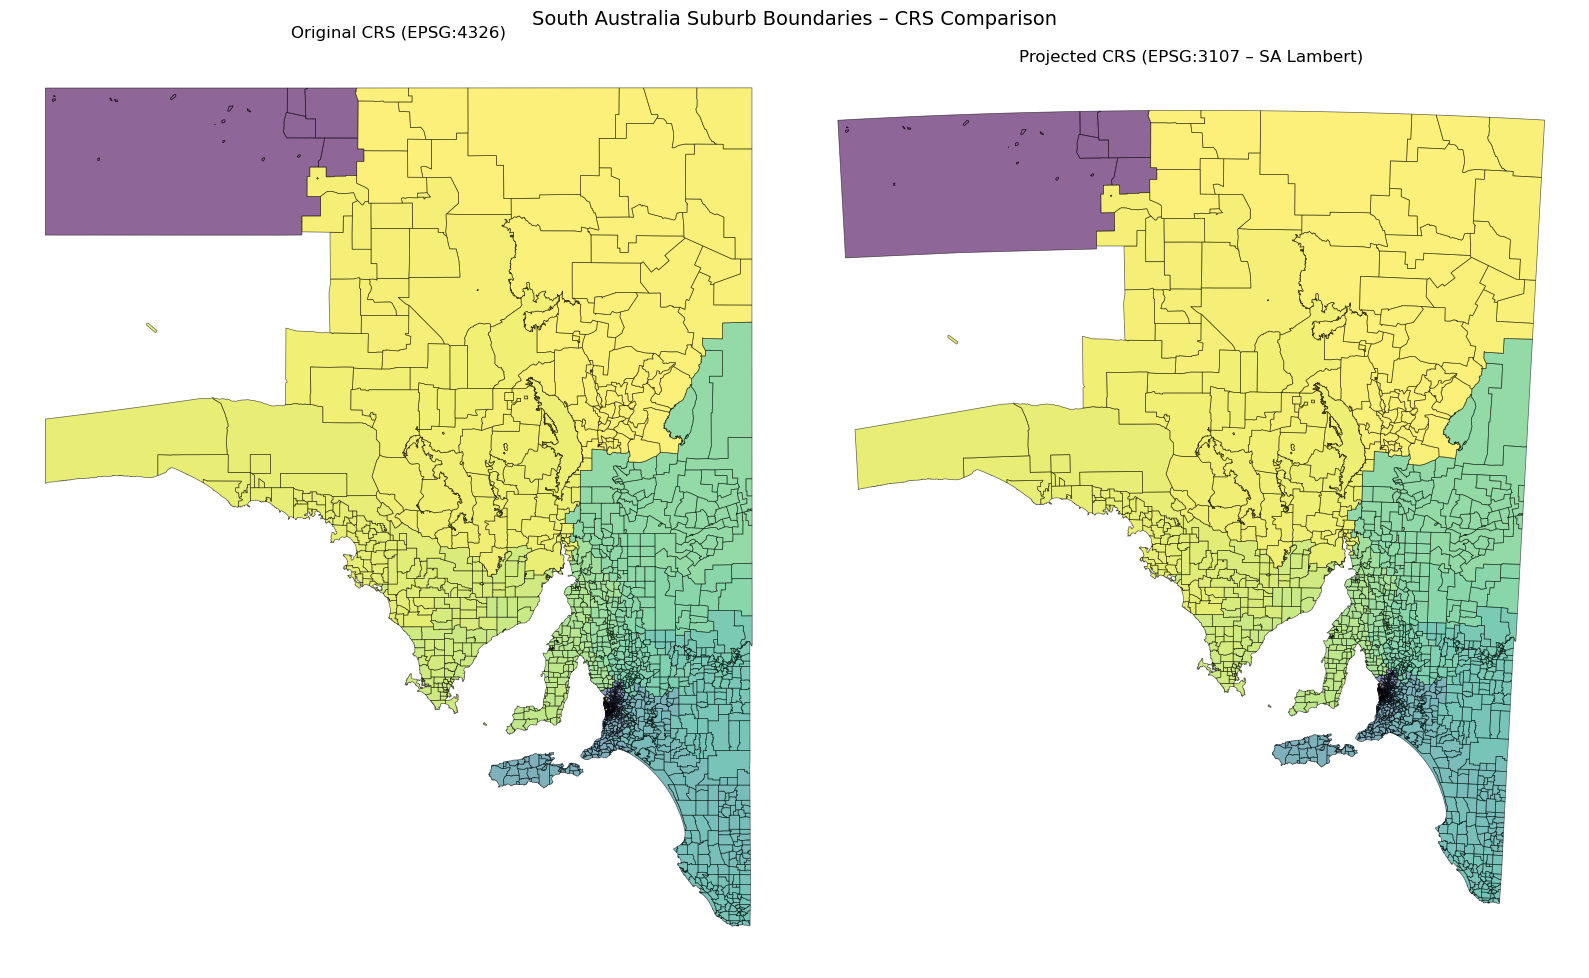

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Plot original CRS
data.plot(
    ax=axes[0],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.6,
    column="postcode",
    cmap="viridis"
)
axes[0].set_title("Original CRS (EPSG:4326)")
axes[0].axis("off")

# Plot projected CRS (EPSG:3107 for SA)
data.to_crs(epsg=3107).plot(
    ax=axes[1],
    edgecolor="black",
    linewidth=0.5,
    alpha=0.6,
    column="postcode",
    cmap="viridis"
)
axes[1].set_title("Projected CRS (EPSG:3107 – SA Lambert)")
axes[1].axis("off")

plt.suptitle("South Australia Suburb Boundaries – CRS Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
import folium

In [16]:
# Calculate center for map
gdf_wgs = data.to_crs(epsg=4326)
gdf_issues_wgs = gdf_issues.to_crs(epsg=4326)

map_center = gdf_wgs.geometry.union_all().centroid
m = folium.Map(location=[map_center.y, map_center.x], zoom_start=9)

gdf_wgs['legalstartdate'] = gdf_wgs['legalstartdate'].astype(str)
# Add base suburb boundaries
folium.GeoJson(
    gdf_wgs,
    name="Suburb Boundaries",
    style_function=lambda x: {
        "fillOpacity": 0.2,
        "color": "blue",
        "weight": 0.5
    },
    tooltip=folium.GeoJsonTooltip(fields=["suburb", "postcode"])
).add_to(m)

# Add mismatched shared boundaries
folium.GeoJson(
    gdf_issues_wgs,
    name="Boundary Inconsistencies",
    style_function=lambda x: {
        "color": "red",
        "weight": 2
    },
    tooltip=folium.GeoJsonTooltip(fields=[])
).add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Save to HTML
m.save("shared_boundary_issues_map.html")
print("Map saved as 'shared_boundary_issues_map.html'")



Map saved as 'shared_boundary_issues_map.html'
